<h1 align="center"><strong><font size="6"> Model Estimation SFMMO Dev World-Cup Edition !! </h1></strong></font>

<br>
<br>

**SFMMO Dev**: development code for the **Soccer Factor Model for Match Outcomes** -- based on **SFM I**.


**SFM I** is the model in [Andorra & Göbel (2024)](https://arxiv.org/abs/2412.05911) -- see notebook `013_SFM_Sloan__Submission.ipynb`.



- Target: Goals of EITHER Team -- i.e. 2 observations per match, and *home pitch* factor becomes explicit:
> - SFMMO DevA: point-diff; goals_scored*; goals_conceded*; MOM; FD_MOM; ELO
> - SFMMO DevD: DevA / {MOM__M; FD_MOM__M}
> - SFMMO DevE: DevA / {goals_scored*, goals_conceded*}
> - SFMMO DevF: DevA / {MOM, FD_MOM}
> - SFMMO DevG: DevA / {ELO}
> - SFMMO DevH: DevA / {FD_MOM}
> - SFMMO DevI: point-diff; ELO

<br>



In [1]:
# --- Connect to Google-Drive
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -qq "pymc<6" numpyro pymc-bart
!pip install -qq plotly
!pip install -qq preliz
!pip install -qq graphviz
!pip install -qq arviz arviz-plots
!pip install -qq jax[cuda] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

In [3]:
from typing import List, Union


# --- Usual Libraries:
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- PyMC & Affiliates
#import arviz as az
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import arviz_plots as azp
import arviz_stats
import xarray as xr
import copy


# --- BART
import pymc_bart as pmb


# --- Stats
from scipy.stats import norm, nbinom, poisson
from sklearn.preprocessing import StandardScaler

# --- Interactive Plots:
import plotly.graph_objects as go
import plotly

# --- Plotting:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns

seed = sum(map(ord, "sfm"))
rng = np.random.default_rng(seed)

pm.__version__

'5.28.5'

In [4]:
np.__version__

'2.0.2'

In [5]:
# -------------------------------------- USER INTERACTION -------------------------------------- #

# --- Set the directory to the datafile ('data_byPlayer__SFM_II__TM__WM.csv'):
directory = '../'

# --- Which 'seasons' are in the Training-Set, which are in the Validation-Set?
# --- --- Each Training-/Val-Set combination needs to be a separate list
dict_EW = {'trainT':[['WMQ2010','WM2010','WMQ2014','WM2014','WMQ2018','WM2018'],['WMQ2010','WM2010','WMQ2014','WM2014','WMQ2018','WM2018','WMQ2022']],
           'valT':[['WMQ2022'],['WM2022']]}

# --- Cross-Sectional Standardization, or whole-sample Standardization?
do__scaleCS = True

# --- Which Dev-Version?
devVersion = 'A'

# -------------------------------------- USER INTERACTION -------------------------------------- #

<br>

## 00 &emsp; Auxiliaries

In [6]:
def compute_log_likelihood(predictions, actuals):
    """
    predictions: array of shape (n_samples, n_categories)
                 e.g., [[0.4, 0.35, 0.2, 0.05], ...] for one match
    actuals: array of actual outcomes [0, 1, 2, 3, ...]
    """
    log_lik = 0
    for i, actual in enumerate(actuals):
        # Get probability assigned to actual outcome
        prob_actual = predictions[i][actual]
        log_lik += np.log(prob_actual + 1e-10)  # Add small epsilon to avoid log(0)

    return log_lik


def log_loss_categorical(probs, actuals, eps=1e-10):
    return -np.mean(np.log(probs[np.arange(len(actuals)), actuals] + eps))


def multi_class_brier_score(predictions, actuals, n_classes=4):
    """
    predictions: (n_samples, n_classes) probability matrix
    actuals: (n_samples,) actual outcomes
    """
    # Convert actuals to one-hot encoding
    one_hot = np.zeros((len(actuals), n_classes))
    one_hot[np.arange(len(actuals)), actuals] = 1

    # Compute Brier score
    brier = np.mean(np.sum((predictions - one_hot)**2, axis=1))
    return brier


def ranked_probability_score(predictions, actuals, n_classes=4):
    """
    Ranked Probability Score for ordinal outcomes
    """
    rps = 0
    for i, actual in enumerate(actuals):
        # Cumulative probabilities
        pred_cumsum = np.cumsum(predictions[i])

        # Actual cumulative (one-hot converted to cumulative)
        actual_cumsum = np.zeros(n_classes)
        actual_cumsum[actual:] = 1

        # RPS for this prediction
        rps += np.sum((pred_cumsum - actual_cumsum)**2)

    return rps / len(actuals)



def expected_calibration_error(predictions, actuals, n_bins=10):
    """
    ECE for probabilistic predictions
    """
    # Get predicted probabilities for actual class
    pred_probs = predictions[np.arange(len(actuals)), actuals]

    # Create bins
    bin_edges = np.linspace(0, 1, n_bins + 1)

    ece = 0
    for i in range(n_bins):
        # Find predictions in this bin
        in_bin = (pred_probs >= bin_edges[i]) & (pred_probs < bin_edges[i+1])

        if np.sum(in_bin) > 0:
            # Average predicted probability in bin
            avg_pred = np.mean(pred_probs[in_bin])

            # Actual accuracy in bin (for max predicted class)
            max_pred = np.argmax(predictions[in_bin], axis=1)
            avg_actual = np.mean(max_pred == actuals[in_bin])

            # Weighted by bin size
            ece += np.abs(avg_pred - avg_actual) * np.sum(in_bin)

    return ece / len(actuals)


def ordinal_accuracy(predictions, actuals):
    """
    Percentage of times the highest probability category was correct
    """
    pred_classes = np.argmax(predictions, axis=1)
    return np.mean(pred_classes == actuals)


def ordinal_mae(predictions, actuals):
    """
    MAE treating categories as ordinal
    """
    pred_classes = np.argmax(predictions, axis=1)
    return np.mean(np.abs(pred_classes - actuals))


def update_elo(r_home, r_away, result, K=20, home_adv=50):
    exp_home = 1 / (1 + 10 ** ((r_away - r_home - home_adv) / 400))
    if result == 2:    # home win
        s_home = 1.0
    elif result == 1:  # draw
        s_home = 0.5
    elif result == 0:  # away win
        s_home = 0.0
    else:
        raise ValueError("Invalid result value. Must be 0, 1, or 2.")

    r_home_new = r_home + K * (s_home - exp_home)
    r_away_new = r_away + K * ((1 - s_home) - (1 - exp_home))
    return r_home_new, r_away_new



def softmax(x):
    return np.exp(x)/sum(np.exp(x))

In [7]:
def rootogram(obs_counts, pp_counts, max_val=8, title=""):
    """
    obs_counts : 1D int array of observed goal counts        (n_fixtures,)
    pp_counts  : 2D int array of posterior predictive counts (n_fixtures, n_samples)
    """
    obs_counts = np.asarray(obs_counts, dtype=int)
    pp_counts  = np.asarray(pp_counts,  dtype=int)

    xs = np.arange(max_val + 1)
    obs_freq = np.bincount(obs_counts, minlength=max_val + 1)[:max_val + 1]

    n_samp = min(pp_counts.shape[1], 200)
    exp_freq = np.array([
        np.bincount(pp_counts[:, s], minlength=max_val + 1)[:max_val + 1]
        for s in range(n_samp)
    ])  # shape (n_samp, max_val+1)

    exp_mean = exp_freq.mean(axis=0)
    exp_low  = np.quantile(exp_freq, 0.03, axis=0)
    exp_up   = np.quantile(exp_freq, 0.97, axis=0)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(xs, np.sqrt(obs_freq), alpha=0.5, label="observed")
    ax.plot(xs, np.sqrt(exp_mean), "ro-", label="expected (PP mean)")
    ax.fill_between(xs, np.sqrt(exp_low), np.sqrt(exp_up),
                    color="red", alpha=0.2, label="94% HDI")
    ax.set_xlabel("goals"); ax.set_ylabel("√frequency"); ax.set_title(title)
    ax.legend(); plt.show()

    print(f"\nRMSE: {np.round(np.sqrt(np.mean((obs_freq - exp_mean))),3)}")
    print(f"Diff: {np.round((obs_freq - exp_mean) / obs_freq,2)}\n")

In [8]:
def get__perMatch_jointPMF(eta, idx_home, idx_away, scale=None, k_max=5):
    """
    For every row in the training set, return the posterior-predictive PMF
    P(Y = k) for k = 0..k_max with credible intervals.

    Returns a long-format DataFrame: (obs_id, k, mean, lo, hi).
    """

    # --- 1. Stack chain × draw → samples
    lam_samples = np.exp(eta.stack(samples=("chain", "draw")).values)    # (n_obs, n_samples)

    # --- Extract Home-Away Match-Ups
    lam_h = lam_samples[idx_home, :]            # (n_fixtures, n_samples)
    lam_a = lam_samples[idx_away, :]


    # --- Probability of Number of Goals to Evaluate
    N_goals = np.arange(k_max + 1)

    # --- 2. PMFs per sample
    if scale is not None:
      scale_samples = scale.stack(samples=("chain", "draw")).values  # (n_samples,)
      # nbinom.pmf with broadcasting: (k_max+1, n_fixtures, n_samples)
      pmf_h = nbinom.pmf(
          N_goals[:, None, None],
          n=scale_samples[None, None, :],
          p=scale_samples[None, None, :] / (scale_samples[None, None, :] + lam_h[None, :, :]),
      )  # (k_max+1, n_fixtures, n_samples)
      pmf_a = nbinom.pmf(
          N_goals[:, None, None],
          n=scale_samples[None, None, :],
          p=scale_samples[None, None, :] / (scale_samples[None, None, :] + lam_a[None, :, :]),
      )
    else:
      # poisson.pmf with broadcasting: (k_max+1, n_fixtures, n_samples)
      pmf_h = poisson.pmf(N_goals[:, None, None],mu=lam_h[None, :, :])
      pmf_a = poisson.pmf(N_goals[:, None, None],mu=lam_a[None, :, :])

    # --- 3. Outer product per fixture per sample → joint
    # einsum: 'h f s, a f s -> f s h a'
    joint = np.einsum("hfs,afs->fsha", pmf_h, pmf_a)


    return joint



def get__home_WDL(matchup_jointPMF,cred_region=0.9):

  """
  matchup_jointPMF: (n_samples, K, K) joint PMF for one fixture
  """
  # Per-sample W/D/L
  diag_idx = np.arange(matchup_jointPMF.shape[-1])

  p_draw = matchup_jointPMF[:, diag_idx, diag_idx].sum(axis=-1)   # (n_samples,)
  p_loss = np.triu(matchup_jointPMF, k=1).sum(axis=(-2, -1))      # away > home (home loss)
  p_win  = np.tril(matchup_jointPMF, k=-1).sum(axis=(-2, -1))     # home > away

  alpha_lo = (1 - cred_region) / 2
  alpha_hi = 1 - alpha_lo

  df = pd.DataFrame(index=['W', 'D', 'L'], columns=['low', 'mid', 'up'], dtype=float)
  for label, arr in [('W', p_win), ('D', p_draw), ('L', p_loss)]:
      df.loc[label, 'mid'] = arr.mean()
      df.loc[label, 'low'] = np.quantile(arr, alpha_lo)
      df.loc[label, 'up']  = np.quantile(arr, alpha_hi)


  return df

## 1 &emsp; The Grand Loop

In [9]:
# ======================================== Quick Check before Firing it Off ======================================== #

data_raw = pd.read_csv(f"{directory}/10_data/data_byPlayer__SFM_II__TM__WM.csv")

# --- Since we do "cross-sectional" standardization by 'gameday'
#     and the data is a bit quirky on identifying exact gamedays for some confederations, let's check that we have
#     enough observations per gameday

data_raw['gameday'].value_counts()


# ---> Better than I expected. Gameday 30 is a bit on thin ice, but let's roll with it anyway.

/tmp/ipykernel_29833/1589369802.py:3: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f"{directory}/10_data/102_Development/data_byPlayer__SFM_II__TM__WM.csv")


,count
gameday,
1.0,5189
6.0,3016
5.0,2849
2.0,2837
4.0,2657
7.0,2604
3.0,2473
9.0,1620
8.0,1507


In [10]:
# ======================================== The Grand Loop ======================================== #

dict_preds = {key[0]: {} for key in dict_EW['valT']}
dict_fitEval = {key[0]: {} for key in dict_EW['valT']}



for t in range(len(dict_EW['trainT'])):



  # --- Extract Training-End and Validation Season:
  train_end = dict_EW['trainT'][t]
  if type(dict_EW['valT'][t]) == list:
    val_seasons = dict_EW['valT'][t]
  elif type(dict_EW['valT'][t]) == str:
    val_seasons = [dict_EW['valT'][t]]

  # --------------------------------- 00. Data Preparation --------------------------------- #
  data_raw = pd.read_csv(f"{directory}/10_data/data_byPlayer__SFM_II__TM__WM.csv")

  # --- Kick 'wm-qualifikation-ozeanien': too few seasons in the training-set
  #data_raw = data_raw[~(data_raw['name_league'] == 'wm-qualifikation-ozeanien')]

  # --- Pre-Processing, Part I:
  data_raw['kick_off'] = pd.to_datetime(data_raw['kick_off'])
  data_raw = data_raw.sort_values(['name_player','season','kick_off'])

  # --- Columns to Keep:
  keepCols = ['points_team','points_opp','goalsscored_inGame_team','goalsscored_inGame_opp',
            'goalsscored_cum_team','goalsscored_cum_opp','goalsconceded_cum_team','goalsconceded_cum_opp',
            'home_pitch','goalsscored_rank_team','goalsconceded_rank_opp',
            'id_match','name_team','name_opp','name_league','id_league','season','gameday','kick_off',
            'goalsscored_rank_opp','goalsconceded_rank_team','goalsscored_diff',
            'goal_balance_team','goal_balance_opp','goal_balance_diff','points_diff',
            'tm_marketvalue_team_squad','tm_marketvalue_opp_squad']

  # --- Extract unique Matches:
  complete_data = data_raw.drop_duplicates(subset=['id_match','home_pitch'])[keepCols].copy().sort_values(['name_league','kick_off']).reset_index(drop=True)

  # --- Keep only Matches for which we observe both Home & Away Team:
  complete_data = complete_data.loc[complete_data['id_match'].duplicated(keep=False),:]


  # Note:       We need two observations per match. This is preserved here.
  #             The home team is identified by the 'home_pitch' indicator.
  # Important:  Each observation is to be seen from the perspective of the TEAM --- but that does not say if TEAM plays at home!
  #             Hence, we can model the target easily, by taking the TEAM variable as the anchor!

  # --- Target: Number of Goals
  complete_data['match_outcome'] = complete_data['goalsscored_inGame_team'].copy()




  # -------------------------------------------- Feature Engineering -- Part I -------------------------------------------- #

  # --- Some Game-Day-Adjustments are necessary -- especially for cross-sectional scaling if a Gameday is '14.1', give it some grace and set it to '14'.
  complete_data['gameday_orig'] = complete_data['gameday'].copy()
  complete_data['gameday'] = [int(float(i.split('_')[1][2:])) for i in complete_data['id_match'].values]


  # -------------------------------------------- ELO Ratings -------------------------------------------- #
  complete_data[['elo_team','elo_opp']] = np.nan

  # --- For Compatibility:
  complete_data['match_outcome__home'] = 1
  complete_data.loc[complete_data['goalsscored_inGame_team'] > complete_data['goalsscored_inGame_opp'],'match_outcome__home'] = 2
  complete_data.loc[complete_data['goalsscored_inGame_team'] < complete_data['goalsscored_inGame_opp'],'match_outcome__home'] = 0




  # --- Run over Leagues
  N_leagues = complete_data['name_league'].unique().tolist()


  for ll in N_leagues:

    #print(f'\nELO-Ratings for league: {ll}')

    # --- Store the ELO ratings:
    ELO_rating = {key: 1500 for key in complete_data.loc[complete_data['name_league'] == ll,'name_team'].unique()}


    # --- Available Seasons:
    N_seasons = complete_data.loc[complete_data['name_league'] == ll,'season'].unique().tolist()


    # --- Run across the season:
    for ss in N_seasons:

      # --- Extract the season:
      ll_ss_data = complete_data[(complete_data['name_league'] == ll) & (complete_data['season'] == ss)].copy().sort_values('kick_off')


      # --- At the beginning of the season, adjust the rating:
      ss_idx = N_seasons.index(ss)
      if ss_idx > 0:

        # --- Teams in previous season:
        ss_t1__teams = complete_data.loc[(complete_data['name_league'] == ll) & (complete_data['season'] == N_seasons[ss_idx-1]),'name_team'].unique().tolist()

        for team in ELO_rating.keys():
          if team in ss_t1__teams:
            ELO_rating[team] = ELO_rating[team] * 0.75 + 1500 * 0.25
          else:
            ELO_rating[team] = 1300


      # --- Run across the season:
      for gg in range(ll_ss_data.shape[0]):

        # --- Home Team:
        gg_home = ll_ss_data['name_team'].iloc[gg]

        # --- Away Team:
        gg_away = ll_ss_data['name_opp'].iloc[gg]

        # --- Get Current ELO Ratings:
        gg_home__elo = ELO_rating[gg_home]
        gg_away__elo = ELO_rating[gg_away]

        # --- Insert Current ELO Ratings:
        gg_idx = ll_ss_data.index[gg]
        complete_data.loc[gg_idx,'elo_team'] = gg_home__elo
        complete_data.loc[gg_idx,'elo_opp'] = gg_away__elo

        # --- Update ELO Ratings:
        ELO_rating[gg_home], ELO_rating[gg_away] = update_elo(gg_home__elo,gg_away__elo,ll_ss_data['match_outcome__home'].iloc[gg])




  complete_data['elo_diff'] = complete_data['elo_team'] - complete_data['elo_opp']
  complete_data['elo_team_opp'] = complete_data['elo_team'] * complete_data['elo_opp']


  # ======================================== Feature Engineering --- Part II ======================================== #

  # --- Goal Appeal (of the match):
  complete_data['goal_appeal'] = complete_data['goalsconceded_rank_opp'] - complete_data['goalsscored_rank_team']



  # ---------------------- Team Momentum - exponentially-weighted MA of previous goals/outcomes ---------------------- #

  # --- For Compatibility: ---> BUT BE CAREFUL TO DROP IT AS IT IS JUST A HELPER!
  complete_data['home_team'] = complete_data['name_team']

  complete_data = complete_data.set_index(['kick_off','season','id_match','home_team'])
  complete_data[['teamMOM__S','teamMOM__M','teamMOM__L','oppMOM__S','oppMOM__M','oppMOM__L','team__FD_points']] = np.nan
  complete_data[['FD_teamMOM__S','FD_teamMOM__M','FD_teamMOM__L','FD_oppMOM__S','FD_oppMOM__M','FD_oppMOM__L']] = np.nan

  for tt in complete_data['name_team'].unique():

    # --- Extract the data for team 'tt'
    tt_data = complete_data.loc[(complete_data['name_team'] == tt) | (complete_data['name_opp'] == tt),:].copy()

    # --- Calculate the Cumulative Points:
    tt_points = pd.DataFrame(np.nan, index=tt_data.index,columns=['home','points'])
    tt_points['points'] = np.where(tt_data['name_team'] == tt, tt_data['points_team'], tt_data['points_opp'])
    tt_points['home'] = np.where(tt_data['name_team'] == tt, 1, 0)

    # --- FD of points
    tt_points['FD_points'] = tt_points.groupby('season')['points'].diff()
    # --- Calculate MOMENTUM: EWMA of points in previous games (halflife == one appearance)
    tt_points['MOM__S'] = tt_points.groupby(level='season')['FD_points'].ewm(halflife=1).mean().droplevel(level=0)
    tt_points['MOM__M'] = tt_points.groupby(level='season')['FD_points'].ewm(halflife=4).mean().droplevel(level=0)
    tt_points['MOM__L'] = tt_points.groupby(level='season')['FD_points'].ewm(halflife=8).mean().droplevel(level=0)

    # --- Calculate Delta MOMENTUM: first-difference of MOMENTUM
    tt_points['FD_MOM__S'] = tt_points.groupby(level='season')['MOM__S'].diff()
    tt_points['FD_MOM__M'] = tt_points.groupby(level='season')['MOM__M'].diff()
    tt_points['FD_MOM__L'] = tt_points.groupby(level='season')['MOM__L'].diff()


    # --- Winsorize ---> well, deprecated
    #tt_points.loc[tt_points['FD_points'] > 3,'FD_points'] = 3

    # --- Fill the data: 'tt' == home team
    idx = complete_data[complete_data['name_team'] == tt].index.intersection(tt_points.index)
    complete_data.loc[idx,['teamMOM__S','teamMOM__M','teamMOM__L','FD_teamMOM__S','FD_teamMOM__M','FD_teamMOM__L','team__FD_points']] = tt_points.loc[tt_points['home'] == 1,['MOM__S','MOM__M','MOM__L','FD_MOM__S','FD_MOM__M','FD_MOM__L','FD_points']].copy().values

    # --- Fill the data: 'tt' == opponent team
    idx = complete_data[complete_data['name_opp'] == tt].index.intersection(tt_points.index)
    complete_data.loc[idx,['oppMOM__S','oppMOM__M','oppMOM__L','FD_oppMOM__S','FD_oppMOM__M','FD_oppMOM__L']] = tt_points.loc[tt_points['home'] == 0,['MOM__S','MOM__M','MOM__L','FD_MOM__S','FD_MOM__M','FD_MOM__L']].copy().values


  # --- Some Two-Way Interactions:
  complete_data['teamMOM__S_L'] = complete_data['teamMOM__S'] * complete_data['teamMOM__L']
  complete_data['oppMOM__S_L'] = complete_data['oppMOM__S'] * complete_data['oppMOM__L']


  # --- Reset index & IMPORTANT: DROP 'home_team'
  complete_data = complete_data.reset_index().drop('home_team',axis=1)


  # ======================================== Feature Engineering -- Part III ======================================== #

  # -------------------------------------------- Transfermarket Market-Values -------------------------------------------- #

  # --- TM Ratio:
  complete_data['tm_marketvalue_ratio'] = complete_data['tm_marketvalue_team_squad'] / complete_data['tm_marketvalue_opp_squad']

  # --- Log-Transform the Raw Values
  complete_data['tm_marketvalue_team_squad'] = np.where(complete_data['tm_marketvalue_team_squad'] <= 0, 0, np.log(complete_data['tm_marketvalue_team_squad']))
  complete_data['tm_marketvalue_opp_squad'] = np.where(complete_data['tm_marketvalue_opp_squad'] <= 0, 0, np.log(complete_data['tm_marketvalue_opp_squad']))


  # ======================================== Define the Factors ======================================== #


  if devVersion in ['A']:

    # --- Numerical Factors:
    factors_CS = ['points_diff',
                  'goalsscored_cum_team','goalsscored_cum_opp',
                  'goalsconceded_cum_team','goalsconceded_cum_opp',
                  'teamMOM__S','oppMOM__S',
                  'teamMOM__M','oppMOM__M',
                  'teamMOM__L','oppMOM__L',
                  'teamMOM__S_L', 'oppMOM__S_L',
                  'FD_teamMOM__S','FD_oppMOM__S',
                  'FD_teamMOM__M','FD_oppMOM__M',
                  'FD_teamMOM__L','FD_oppMOM__L',
                  'elo_team','elo_opp',
                  'elo_team_opp'
                  ]

  elif devVersion in ['D']:

    # --- Numerical Factors:
    factors_CS = ['points_diff',
                  'teamMOM__S','oppMOM__S',
                  'teamMOM__M','oppMOM__M',
                  'teamMOM__L','oppMOM__L',
                  'teamMOM__S_L', 'oppMOM__S_L',
                  'FD_teamMOM__S','FD_oppMOM__S',
                  'FD_teamMOM__M','FD_oppMOM__M',
                  'FD_teamMOM__L','FD_oppMOM__L',
                  'elo_team','elo_opp',
                  'elo_team_opp'
                  ]

  elif devVersion in ['E']:

    # --- Numerical Factors:
    factors_CS = ['points_diff',
                  'goalsscored_cum_team','goalsscored_cum_opp',
                  'goalsconceded_cum_team','goalsconceded_cum_opp',
                  'teamMOM__S','oppMOM__S',
                  #'teamMOM__M','oppMOM__M',
                  'teamMOM__L','oppMOM__L',
                  'teamMOM__S_L', 'oppMOM__S_L',
                  'FD_teamMOM__S','FD_oppMOM__S',
                  #'FD_teamMOM__M','FD_oppMOM__M',
                  'FD_teamMOM__L','FD_oppMOM__L',
                  'elo_team','elo_opp',
                  'elo_team_opp'
                  ]

  elif devVersion in ['F']:

    # --- Numerical Factors:
    factors_CS = ['points_diff',
                  'goalsscored_cum_team','goalsscored_cum_opp',
                  'goalsconceded_cum_team','goalsconceded_cum_opp',
                  #'teamMOM__S','oppMOM__S',
                  #'teamMOM__M','oppMOM__M',
                  #'teamMOM__L','oppMOM__L',
                  #'teamMOM__S_L', 'oppMOM__S_L',
                  #'FD_teamMOM__S','FD_oppMOM__S',
                  #'FD_teamMOM__M','FD_oppMOM__M',
                  #'FD_teamMOM__L','FD_oppMOM__L',
                  'elo_team','elo_opp',
                  'elo_team_opp'
                  ]

  elif devVersion in ['G']:

    # --- Numerical Factors:
    factors_CS = ['points_diff',
                  'goalsscored_cum_team','goalsscored_cum_opp',
                  'goalsconceded_cum_team','goalsconceded_cum_opp',
                  'teamMOM__S','oppMOM__S',
                  'teamMOM__M','oppMOM__M',
                  'teamMOM__L','oppMOM__L',
                  'teamMOM__S_L', 'oppMOM__S_L',
                  'FD_teamMOM__S','FD_oppMOM__S',
                  'FD_teamMOM__M','FD_oppMOM__M',
                  'FD_teamMOM__L','FD_oppMOM__L'
                  #'elo_team','elo_opp',
                  #'elo_team_opp'
                  ]

  elif devVersion in ['H']:

    # --- Numerical Factors:
    factors_CS = ['points_diff',
                  'goalsscored_cum_team','goalsscored_cum_opp',
                  'goalsconceded_cum_team','goalsconceded_cum_opp',
                  'teamMOM__S','oppMOM__S',
                  'teamMOM__M','oppMOM__M',
                  'teamMOM__L','oppMOM__L',
                  'teamMOM__S_L', 'oppMOM__S_L',
                  #'FD_teamMOM__S','FD_oppMOM__S',
                  #'FD_teamMOM__M','FD_oppMOM__M',
                  #'FD_teamMOM__L','FD_oppMOM__L'
                  'elo_team','elo_opp',
                  'elo_team_opp'
                  ]

  elif devVersion in ['I']:

    # --- Numerical Factors:
    factors_CS = ['points_diff',
                  'elo_team','elo_opp',
                  'elo_team_opp'
                  ]



  # --- Other Factors:
  other_factors = ['home_pitch']


  # --- Concatenate:
  factors = other_factors + factors_CS

  # ======================================== Target & ID vars ======================================== #

  IDvar = ['id_match','name_team','name_opp','name_league','id_league','season','gameday','kick_off']
  Yvar = 'match_outcome'




  # ======================================== Some Data Preprocessing ======================================== #


  # --- 0.0 Winsorize the Number of Goals in a Game:
  complete_data['match_outcome__orig'] = complete_data['match_outcome'].copy()
  complete_data['match_outcome'] = np.where(complete_data['match_outcome'] > 7, 7, complete_data['match_outcome'])


  # --- 0.0 Special Treatment:
  complete_data = complete_data[IDvar + [Yvar] + factors].dropna().reset_index(drop=True)


  # --- 0.1 Validation Set:
  data_oos = complete_data.loc[complete_data['season'].isin(val_seasons),:].dropna()
  data_oos = data_oos.loc[data_oos['name_league'].isin(complete_data.loc[complete_data['season'].isin(train_end),'name_league']),:]

  # --- 0.2 Get the Training-Data only:
  complete_data = complete_data.loc[complete_data['season'].isin(train_end),:].dropna()

  # --- 0.3 Kick the first Season by League:
  complete_data = complete_data.loc[complete_data.groupby('name_league')['season'].transform('min') != complete_data['season'],:]


  # --- 0.4 Some Type-Setting:
  complete_data["kick_off"] = pd.to_datetime(
      complete_data["kick_off"], yearfirst=True
  ).dt.normalize()


  # --- 0.5 Final Sorting for Convenience:
  complete_data = complete_data.sort_values(["name_league", "kick_off"]).reset_index(
      drop=True
  )



  # ======================================== Cross-Sectional Standardization (by Gameday) ======================================== #

  if do__scaleCS:
    # --- For future use:
    train_means = complete_data.groupby('gameday')[factors_CS].mean()
    train_stds  = complete_data.groupby('gameday')[factors_CS].std()

    # --- Conduct actual scaling:
    data__scaleCS = complete_data.groupby('gameday')[factors_CS].apply(lambda x: (x - x.mean()) / x.std()).reset_index().set_index('level_1').drop('gameday',axis=1)

    print('\nScaling data cross-sectionally!\n')



    # --- Merge:
    complete_data[factors_CS] = data__scaleCS


  # --- Drop NA:
  complete_data = complete_data.dropna()


  # ======================================== 1.1 Factor Standardization ======================================== #

  if not do__scaleCS:
      factors_CS_train = complete_data[factors_CS].copy()

      # --- Do the Standardization
      scaler = StandardScaler()
      factors_CS_sdz = pd.DataFrame(
          scaler.fit_transform(factors_CS_train), columns=factors_CS
      )

      # --- Add the non-numeric factor to the standardized DataFrame
      factors_sdz = factors_CS_sdz.copy()
      factors_sdz[other_factors] = complete_data[other_factors].copy()

      # --- Ensure that the order is the same as the PyMC coords later on
      factors_sdz = factors_sdz[factors]


      print('\nScaling data across the Whole Sample!\n')


  else:

      # --- Standardization already done! Ensure that the order is the same as the PyMC coords later on:
      factors_sdz = complete_data[factors].copy()

      #print('\nData already scaled cross-sectionally!\n')



  # =========================== Changing Variables for Train- & Test-Set =========================== #

  # --- Teams:
  names_teams = sorted(set(complete_data["name_team"]).union(complete_data["name_opp"]))
  team_to_idx = {t: i for i, t in enumerate(names_teams)}


  # --- Home & Away Team Indices:
  idx_home = complete_data[complete_data['home_pitch'] == 1].index
  idx_away = complete_data[complete_data['home_pitch'] == 0].index

  # --- Leagues:
  names_leagues = sorted(set(complete_data["name_league"]))
  league_to_idx = {l: i for i, l in enumerate(names_leagues)}

  # --- Global Factors
  factors_g = [f for f in factors if f != 'home_pitch']

  # --- Set the Coords:
  COORDS = {
      "factor_g": factors_g,
      "obs_id": complete_data.index,
      "outcome_categories": [len(np.unique(complete_data[Yvar])) - 1],
      "teams": names_teams,
      "leagues": names_leagues
  }


  # ========================================= The Team-Factors ========================================= #


  with pm.Model(coords=COORDS) as SFMMO__dev:

      # --- Set the Data:
      X_gf = pm.Data(
          "X_gf", factors_sdz[factors_g].copy().to_numpy(), dims=("obs_id", "factor_g")
      )
      X_home = pm.Data(
          "X_home", factors_sdz['home_pitch'].copy().to_numpy().astype(int), dims="obs_id"
      )
      Y = pm.Data(
          "Y", complete_data[Yvar].copy().to_numpy(), dims="obs_id"
      )
      idx_team = pm.Data("idx_team", complete_data["name_team"].map(team_to_idx).to_numpy(), dims="obs_id")
      idx_opp = pm.Data("idx_opp", complete_data["name_opp"].map(team_to_idx).to_numpy(), dims="obs_id")
      idx_home = pm.Data("idx_home", (complete_data["home_pitch"] == 1).to_numpy(), dims="obs_id")
      idx_league = pm.Data("idx_league", complete_data["name_league"].map(league_to_idx).to_numpy(), dims="obs_id")

      # --- Set the Model Priors:

      if devVersion in ['Z']:

        # --- BART:
        gX = pmb.BART('gX', X, Y ,m=50,shape=(2,'obs_id'))

      else:


        # --- Team-Level Home-Fixed-Effect:
        sigma_alpha = pm.Gamma("sigma_alpha", alpha=2, beta=4)
        alpha_raw   = pm.ZeroSumNormal("alpha_raw", sigma=1, dims="teams")
        alpha       = pm.Deterministic("alpha", alpha_raw * sigma_alpha, dims="teams")

        # --- Team-Level Away-Fixed-Effect:
        sigma_delta = pm.Gamma("sigma_delta", alpha=2, beta=4)
        delta_raw   = pm.Normal("delta_raw", 0, 1, dims="teams")
        delta       = pm.Deterministic("delta", delta_raw * sigma_delta, dims="teams")

        # --- Team-Level Home Advantage:
        mu_gamma    = pm.Normal("mu_gamma", mu=0.30, sigma=0.20)
        sigma_gamma = pm.Gamma("sigma_gamma", alpha=2, beta=20) #pm.HalfNormal("sigma_gamma", sigma=0.10)
        # --- --- Non-centered for sampling stability:
        gamma_raw   = pm.Normal("gamma_raw", 0, 1, dims="teams")
        beta_home  = pm.Deterministic(
            "beta_home",
            mu_gamma + gamma_raw * sigma_gamma,
            dims="teams",
        )

        # --- League Fixed Effect:
        kappa = pm.ZeroSumNormal("kappa", sigma=0.3, dims="leagues")
        #sigma_alpha_league = pm.Gamma("sigma_alpha_league", alpha=2, beta=4, dims="leagues")

        # --- Factors are pooled across teams
        beta = pm.Normal("beta", mu=0, sigma=0.3, dims="factor_g")





  # ==================== Set the Model: Bayesian Time-Series Regression (Classificatuion) ==================== #


  with SFMMO__dev:

      # --- Conditional Mean:
      eta = pm.Deterministic('eta',alpha[idx_team] - delta[idx_opp] + kappa[idx_league] + X_home * beta_home[idx_team] + pt.dot(X_gf, beta.T))
      #eta = pm.Deterministic('eta',alpha[idx_team] * sigma_alpha_league[idx_league] - delta[idx_opp] + X_home * beta_home[idx_team] + pt.dot(X_gf, beta.T))


      if 1==2:
        # --- Variance:
        scale = pm.Gamma("scale", alpha=20, beta=0.1)


        # --- Likelihood:
        pm.NegativeBinomial("match_outcome", mu=pm.math.exp(eta), alpha=scale, observed=Y, dims="obs_id")

      else:

        # --- Likelihood:
        pm.Poisson("match_outcome", mu=pm.math.exp(eta), observed=Y, dims="obs_id")


  # ============================================= Inference! ============================================= #


  # --- In the paper we use 4 chains
  # --- Just for speed: set it to 1
  N_chains = 2

  with SFMMO__dev:

      if devVersion in ['Z']:

        idata = pm.sample(draws=4000, tune=1000, chains=N_chains,cores=4, random_seed=42, idata_kwargs={"log_likelihood": True})

      else:

        idata = pm.sample(nuts_sampler="numpyro",
                          target_accept=0.99,
                          chains=N_chains,
                          draws=4000, tune=1000,
                          cores=1,  # --- CPU cores (irrelevant for GPU)
                          nuts_sampler_kwargs={"chain_method": "vectorized"},
                          idata_kwargs={"log_likelihood": True})  # --- Runs chains in parallel on GPU)



  # ============================= Some Preparation for Post-Estimation Processing ============================= #

  with SFMMO__dev:
      idata.extend(pm.sample_posterior_predictive(idata))




  # ===================================== OOS-Data: Preparation ===================================== #


  # --- 0.1 Some Type-Setting:
  data_oos["kick_off"] = pd.to_datetime(
      data_oos["kick_off"], yearfirst=True
  ).dt.normalize()


  # --- 0.2 Final Sorting for Convenience:
  data_oos = data_oos.sort_values(["name_league", "kick_off"]).reset_index(
      drop=True
  )

  if do__scaleCS:
    #data__scaleCS = data_oos.groupby('gameday')[factors_CS].apply(lambda x: (x - x.mean()) / x.std()).reset_index().set_index('level_1').drop('gameday',axis=1)

    # --- Merge:
    #data_oos[factors_CS] = data__scaleCS
    data_oos[factors_CS] = data_oos.apply(lambda row: (row[factors_CS] - train_means.loc[row['gameday']]) / train_stds.loc[row['gameday']], axis=1)


    print('\nScaling Data Cross-Sectionally!\n')


  else:

      # --- Standardization already done! Ensure that the order is the same as the PyMC coords later on:
      print('\nNo Sclaing Applied!\n')


  factors_sdz__oos = data_oos[factors].copy()



  # ================================== Out-of-Sample Prediction ================================== #


  # --- Identify the Teams:
  teams_in_oos = set(data_oos["name_team"]).union(data_oos["name_opp"])
  truly_new_teams = sorted(t for t in teams_in_oos if t not in names_teams)

  # --- Combined coord: training teams first, then new teams
  names_teams_all = list(names_teams) + truly_new_teams
  team_to_idx_all = {t: i for i, t in enumerate(names_teams_all)}

  n_train = len(names_teams)
  n_new   = len(truly_new_teams)


  # --- Identify the Leagues (sanity check: any leagues unseen in training?)
  leagues_in_oos = sorted(set(data_oos["name_league"]))
  unknown_leagues = [l for l in leagues_in_oos if l not in league_to_idx]
  if unknown_leagues:
      raise ValueError(
          f"OOS data contains leagues not seen in training: {unknown_leagues}. "
          f"You'll need to handle these explicitly (e.g., kappa__new with a prior)."
      )


  # ---------------------------- Update the Model ---------------------------- #
  with SFMMO__dev:

      # New coords
      if n_new > 0:
          SFMMO__dev.add_coord("team__new", truly_new_teams)
      SFMMO__dev.add_coord("obs_id__oos", data_oos.index)

      # OOS data containers
      X_gf_oos    = pm.Data("X_gf_oos",
                            factors_sdz__oos.loc[data_oos.index, factors_g].to_numpy(),
                            dims=("obs_id__oos", "factor_g"))
      X_home_oos  = pm.Data("X_home_oos",
                            factors_sdz__oos.loc[data_oos.index, "home_pitch"].to_numpy().astype(int),
                            dims="obs_id__oos")
      idx_team_oos = pm.Data("idx_team_oos",
                            data_oos["name_team"].map(team_to_idx_all).to_numpy(),
                            dims="obs_id__oos")
      idx_opp_oos  = pm.Data("idx_opp_oos",
                            data_oos["name_opp"].map(team_to_idx_all).to_numpy(),
                            dims="obs_id__oos")
      idx_home_oos = pm.Data("idx_home_oos",
                            (data_oos["home_pitch"] == 1).to_numpy().astype(int),
                            dims="obs_id__oos")
      idx_league_oos = pm.Data("idx_league_oos",                          # ← NEW
                              data_oos["name_league"].map(league_to_idx).to_numpy(),
                              dims="obs_id__oos")
      Y_oos        = pm.Data("Y_oos",
                            data_oos[Yvar].to_numpy().astype(int),
                            dims="obs_id__oos")

      # ============ New-team parameters (only if any) ============
      if n_new > 0:
          # Reference shared hyperparameters and globals from training
          sigma_alpha_hp = SFMMO__dev.sigma_alpha
          sigma_delta_hp = SFMMO__dev.sigma_delta
          mu_gamma_hp    = SFMMO__dev.mu_gamma
          sigma_gamma_hp = SFMMO__dev.sigma_gamma

          # Empirical anchors for new teams (25th-pct heuristic; consider promoted-team mean instead)
          alpha_anchor = idata['posterior']['alpha'].stack(samples=('chain','draw'))\
                          .median('samples').quantile(0.25).to_numpy()
          delta_anchor = idata['posterior']['delta'].stack(samples=('chain','draw'))\
                          .median('samples').quantile(0.25).to_numpy()

          alpha__new = pm.Normal("alpha__new",
                                mu=alpha_anchor, sigma=sigma_alpha_hp,
                                dims="team__new")
          delta__new = pm.Normal("delta__new",
                                mu=delta_anchor, sigma=sigma_delta_hp,
                                dims="team__new")
          gamma_raw__new = pm.Normal("gamma_raw__new", 0, 1, dims="team__new")
          beta_home__new = pm.Deterministic(
              "beta_home__new",
              mu_gamma_hp + gamma_raw__new * sigma_gamma_hp,
              dims="team__new",
          )

          # Combined parameter vectors via concatenation
          alpha_all     = pt.concatenate([alpha,     alpha__new])
          delta_all     = pt.concatenate([delta,     delta__new])
          beta_home_all = pt.concatenate([beta_home, beta_home__new])
      else:
          # No new teams this OOS window — combined is just the trained
          alpha_all     = alpha
          delta_all     = delta
          beta_home_all = beta_home

      # ============ Single OOS linear predictor and likelihood ============
      eta_oos = pm.Deterministic(
          "eta_oos",
          alpha_all[idx_team_oos]
        - delta_all[idx_opp_oos]
        + kappa[idx_league_oos]                   # ← NEW: league fixed effect
        + X_home_oos * beta_home_all[idx_team_oos]
        + pt.dot(X_gf_oos, beta),
          dims="obs_id__oos",
      )

      if 1 == 2:
          pm.NegativeBinomial(
              "match_outcome_oos",
              mu=pm.math.exp(eta_oos),
              alpha=scale,
              observed=Y_oos,
              dims="obs_id__oos",
          )
      else:
          pm.Poisson(
              "match_outcome_oos",
              mu=pm.math.exp(eta_oos),
              observed=Y_oos,
              dims="obs_id__oos",
          )


  # ============ One prediction call for everything ============
  with SFMMO__dev:
      oos_preds = pm.sample_posterior_predictive(
          idata,
          predictions=True,
          var_names=["eta_oos", "match_outcome_oos"]
                    + (["alpha__new", "delta__new", "beta_home__new"] if n_new > 0 else []),
          compile_kwargs={"mode": "NUMBA"},
      )



  # ===================================== Collect Results: Match-Up Goals Matrix ===================================== #


  # --- Assemble the Match-IDs and corresponding Match-Ups:
  Y__eval = data_oos[['id_match','name_team','name_opp','home_pitch','kick_off'] + [Yvar]].copy().reset_index(names='index__data_oos')

  # --- Get Home & Away Indices within the Samples:
  idxSamples_home = Y__eval.loc[Y__eval['home_pitch'] == 1,'id_match'].reset_index().set_index('id_match')
  idxSamples_away = Y__eval.loc[Y__eval['home_pitch'] == 0,'id_match'].reset_index().set_index('id_match')

  idxSamples = pd.merge(idxSamples_home,idxSamples_away,left_index=True,right_index=True, suffixes=('__home','__away'))
  idxSamples_home = idxSamples['index__home'].values
  idxSamples_away = idxSamples['index__away'].values

  # --- Get the Joint Posterior of the Goal-Matrix
  jointPMF = get__perMatch_jointPMF(eta=oos_preds['predictions']['eta_oos'],
                                    #scale=idata['posterior']['scale'],
                                    idx_home=idxSamples_home, idx_away=idxSamples_away,
                                    k_max=5)



  # ===================================== Evaluate Predictions ===================================== #

  Y__SFMMO = pd.DataFrame(columns=['id_match','match_outcome'])
  Yhat = pd.DataFrame(columns=['0','1','2'])


  for m in tqdm(range(len(idxSamples_home))):

    # --- Observed Outcome:
    m_Y = Y__eval.loc[(idxSamples_home[m],idxSamples_away[m]),:].copy().sort_values('home_pitch',ascending=False)
    m_Y__outcome = 2 if m_Y['match_outcome'].diff().values[1] < 0 else 0 if m_Y['match_outcome'].diff().values[1] > 0 else 1
    Y__SFMMO = pd.concat([Y__SFMMO,pd.DataFrame({'id_match':[m_Y['id_match'].iloc[0]],'match_outcome':[m_Y__outcome]})],axis=0).reset_index(drop=True)

    # --- Predicted Probabilities
    m_Yhat = get__home_WDL(jointPMF[m,:,:,:])['mid'].iloc[::-1].values
    Yhat = pd.concat([Yhat,pd.DataFrame(m_Yhat,index=['0','1','2']).T],axis=0).reset_index(drop=True)






  dict_preds[val_seasons[0]] = {'Yhat':Yhat,'Y__SFM':Y__SFMMO}


  # ====================================== For In-Sample Evaluation / Sampling Evaluation ====================================== #
  idx_home = complete_data.loc[complete_data['home_pitch'] == 1, 'id_match'].reset_index().set_index('id_match')
  idx_away = complete_data.loc[complete_data['home_pitch'] == 0, 'id_match'].reset_index().set_index('id_match')

  idx_lookup = pd.merge(idx_home,idx_away, left_index=True, right_index=True, suffixes=('_home','_away'))


  dict_fitEval[val_seasons[0]] = {'idata': idata, 'idx_lookup':idx_lookup}



/tmp/ipykernel_29833/936518087.py:20: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f"{directory}/10_data/102_Development/data_byPlayer__SFM_II__TM__WM.csv")



Scaling data cross-sectionally!



sample: 100%|██████████| 5000/5000 [04:27<00:00, 18.69it/s]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,4000,210], float64[2,4000,6].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Output()


Scaling Data Cross-Sectionally!



...

sample: 100%|██████████| 5000/5000 [04:27<00:00, 18.72it/s]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,4000,212], float64[2,4000,6].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Output()

Output()


Scaling Data Cross-Sectionally!



  0%|          | 0/48 [00:00<?, ?it/s]/tmp/ipykernel_29833/936518087.py:780: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Yhat = pd.concat([Yhat,pd.DataFrame(m_Yhat,index=['0','1','2']).T],axis=0).reset_index(drop=True)
100%|██████████| 48/48 [00:00<00:00, 155.28it/s]


In [11]:
# ================================== Export ================================== #

if 1==1:
  import pickle
  import cloudpickle

  if do__scaleCS:
    scale__type = '_scaleCS' # --- cross-sectional
  else:
    scale__type = '_scaleWS' # --- whole-sample

  pickle_filepath = f'{directory}/10_data/102_Development/Evaluation__SFMMOwm_Dev{devVersion}_{scale__type}__EW.pkl'
  dict_to_save = {
                  'factors': factors,
                  'dict_preds' : dict_preds
                 }

  with open(pickle_filepath , 'wb') as f:
      cloudpickle.dump(dict_to_save, f)


  print(f'Fine. Version: {devVersion}')

Fine. Version: G


<br>

## 2 &emsp; Evaluation -- Fitting


In [16]:
# ------------------------------------- USER INTERACTION ------------------------------------- #

# --- Which EW do you want to evaluate? [integer for the number]
pick_EW = 1

# ------------------------------------- USER INTERACTION ------------------------------------- #


assert pick_EW < len(dict_EW['valT']), f'[ERROR]: only {len(dict_EW['valT'])} Expanding Window periods available!'

# --- For Compatibility:
obs_data = dict_fitEval[dict_EW['valT'][pick_EW][0]]['idata']['observed_data'].copy()
idata = dict_fitEval[dict_EW['valT'][pick_EW][0]]['idata'].copy()
idx_lookup = dict_fitEval[dict_EW['valT'][pick_EW][0]]['idx_lookup'].copy()


In [17]:
# =================================== Sampling Diagnostics =================================== #

arviz_stats.diagnose(idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


False

/usr/local/lib/python3.12/dist-packages/arviz_stats/base/diagnostics.py:1275: RuntimeWarning: invalid value encountered in divide
  len_scale = n * (np.log(-b_ary / k_ary) - k_ary - 1)
/usr/local/lib/python3.12/dist-packages/arviz_stats/base/diagnostics.py:1294: RuntimeWarning: invalid value encountered in scalar divide
  sigma = -kappa / b_post


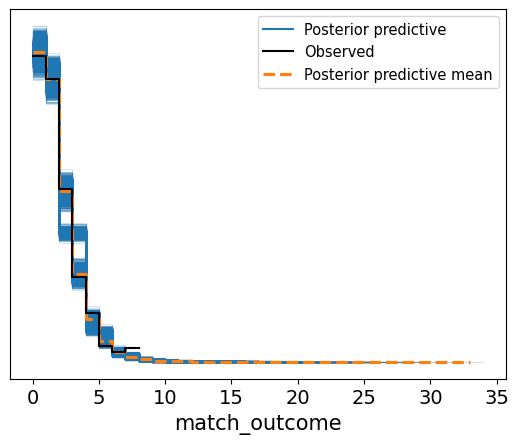

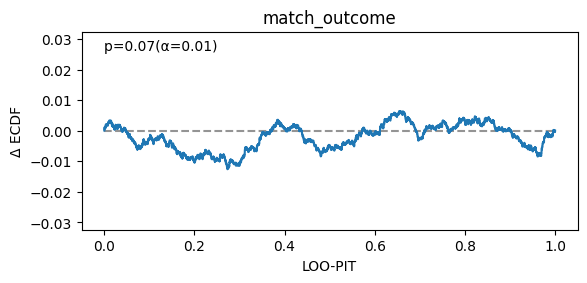

In [18]:
# =================================== Posterior Calibration Diagnostics =================================== #

az.plot_ppc(idata)

azp.plot_loo_pit(idata)

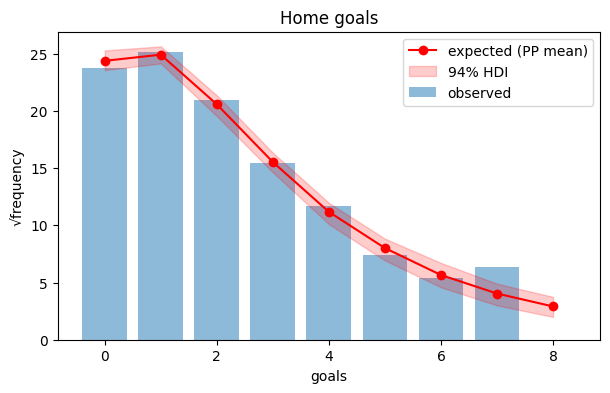


RMSE: 1.1
Diff: [-0.05  0.02  0.04 -0.01  0.08 -0.17 -0.1   0.59  -inf]



/tmp/ipykernel_29833/3020354641.py:31: RuntimeWarning: divide by zero encountered in divide
  print(f"Diff: {np.round((obs_freq - exp_mean) / obs_freq,2)}\n")


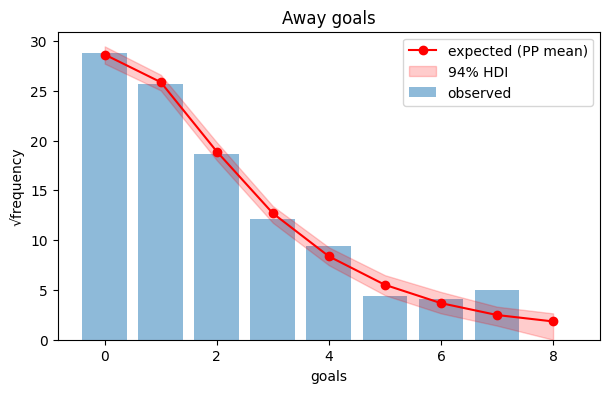


RMSE: 0.624
Diff: [ 0.01 -0.02 -0.02 -0.1   0.2  -0.6   0.21  0.75  -inf]

Observed P(draw)         : 0.208
Posterior predictive mean: 0.214


/tmp/ipykernel_29833/3020354641.py:31: RuntimeWarning: divide by zero encountered in divide
  print(f"Diff: {np.round((obs_freq - exp_mean) / obs_freq,2)}\n")


94% HDI                  : [0.198, 0.231]


In [19]:
# =================================== Calibration: Probability of Draws =================================== #

"""
  P(draw) : Observed probability of a draw

"""


# --- Posterior Home Teams:
pp_home = idata['posterior_predictive']['match_outcome'].stack(samples=('chain','draw'))[idx_lookup['index_home'].values,]

# --- Posterior Away Teams:
pp_away = idata['posterior_predictive']['match_outcome'].stack(samples=('chain','draw'))[idx_lookup['index_away'].values,]

# --- Observations Home Teams:
obs_home = complete_data.loc[idx_lookup['index_home'].values,'match_outcome']

# --- Observations Away Teams:
obs_away = complete_data.loc[idx_lookup['index_away'].values,'match_outcome']

# --- Posterior Outcome:
pp_outcome = pp_home.values - pp_away.values

# --- Observations Outcome:
obs_outcome = obs_home.values - obs_away.values



rootogram(obs_home.astype(int).values, pp_home.values, title="Home goals")
rootogram(obs_away.astype(int).values, pp_away.values, title="Away goals")


print(f"Observed P(draw)         : {(obs_outcome == 0).mean():.3f}")
print(f"Posterior predictive mean: {(pp_outcome == 0).mean(axis=0).mean():.3f}")
print(f"94% HDI                  : [{np.quantile((pp_outcome == 0).mean(axis=0), 0.03):.3f}, "
      f"{np.quantile((pp_outcome == 0).mean(axis=0), 0.97):.3f}]")

In [20]:
# =================================== Calibration: Match Outcomes =================================== #


scorelines_obs = list(zip(obs_home, obs_away))
scorelines_pp_per_sample = [
    list(zip(pp_home.values[:, s], pp_away.values[:, s]))
    for s in range(min(pp_home.shape[1], 500))
]

for h, a in [(0, 0), (1, 1), (2, 2), (3, 3), (1, 0), (0, 1), (2, 1), (1, 2)]:
    p_obs = np.mean([s == (h, a) for s in scorelines_obs])
    p_pp  = np.mean([
        np.mean([s == (h, a) for s in sample]) for sample in scorelines_pp_per_sample
    ])
    print(f"{h}-{a}:  obs={p_obs:.4f}  pred={p_pp:.4f}  diff={p_obs - p_pp:+.4f}")


0-0:  obs=0.0665  pred=0.0829  diff=-0.0164
1-1:  obs=0.1026  pred=0.0929  diff=+0.0097
2-2:  obs=0.0361  pred=0.0319  diff=+0.0042
3-3:  obs=0.0014  pred=0.0059  diff=-0.0045
1-0:  obs=0.1063  pred=0.1040  diff=+0.0023
0-1:  obs=0.0731  pred=0.0837  diff=-0.0106
2-1:  obs=0.0674  pred=0.0640  diff=+0.0035
1-2:  obs=0.0515  pred=0.0521  diff=-0.0006


In [21]:
# =================================== Calibration: Probability of Draws - by League =================================== #


leagues = complete_data.loc[idx_lookup['index_home'].values, "name_league"].to_numpy()
for lg in np.unique(leagues):
    mask = leagues == lg
    p_obs = (obs_outcome[mask] == 0).mean()
    p_pp  = (pp_outcome[mask] == 0).mean(axis=0).mean()
    pp_per_sample = (pp_outcome[mask] == 0).mean(axis=0)
    lo, hi = np.quantile(pp_per_sample, [0.03, 0.97])
    flag = "MISS" if (p_obs < lo or p_obs > hi) else "ok"
    print(f"{lg:>15}  obs={p_obs:.3f}  pred={p_pp:.3f}  HDI=[{lo:.3f}, {hi:.3f}]  {flag}")


weltmeisterschaft  obs=0.135  pred=0.225  HDI=[0.146, 0.312]  MISS
wm-qualifikation-afrika  obs=0.260  pred=0.242  HDI=[0.198, 0.287]  ok
wm-qualifikation-asien  obs=0.185  pred=0.208  HDI=[0.172, 0.245]  ok
wm-qualifikation-europa  obs=0.189  pred=0.199  HDI=[0.171, 0.229]  ok
wm-qualifikation-nordamerika-mittelamerika  obs=0.227  pred=0.212  HDI=[0.165, 0.258]  ok
wm-qualifikation-ozeanien  obs=0.154  pred=0.182  HDI=[0.077, 0.288]  ok
wm-qualifikation-suedamerika  obs=0.253  pred=0.234  HDI=[0.181, 0.287]  ok


<br>

## 3 &emsp; Evaluation -- OOS


In [25]:
# ================================== Out-of-Sample Evaluation ================================== #

df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval.index:

  if s == 'all':
    s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
    s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
  else:
    s__Yhat = dict_preds[s]['Yhat'].values
    s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


  df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

print(f'\nVersion: {devVersion}')
df_eval.round(4)


Version: A


,logLik,ACC,RPS,Brier
WMQ2022,0.8549,0.6642,0.3177,0.4678
WM2022,0.9885,0.6458,0.4379,0.5473
all,0.8637,0.6630,0.3256,0.4730


In [12]:
# ================================== Out-of-Sample Evaluation ================================== #

df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval.index:

  if s == 'all':
    s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
    s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
  else:
    s__Yhat = dict_preds[s]['Yhat'].values
    s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


  df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

print(f'\nVersion: {devVersion}')
df_eval.round(4)


Version: D


,logLik,ACC,RPS,Brier
WMQ2022,0.8771,0.6554,0.3312,0.4789
WM2022,0.9886,0.7083,0.4233,0.5354
all,0.8844,0.6589,0.3373,0.4826


In [12]:
# ================================== Out-of-Sample Evaluation ================================== #

df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval.index:

  if s == 'all':
    s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
    s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
  else:
    s__Yhat = dict_preds[s]['Yhat'].values
    s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


  df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

print(f'\nVersion: {devVersion}')
df_eval.round(4)


Version: E


,logLik,ACC,RPS,Brier
WMQ2022,0.8551,0.6642,0.3179,0.4681
WM2022,0.9903,0.6458,0.4390,0.5487
all,0.8640,0.6630,0.3258,0.4734


In [12]:
# ================================== Out-of-Sample Evaluation ================================== #

df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval.index:

  if s == 'all':
    s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
    s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
  else:
    s__Yhat = dict_preds[s]['Yhat'].values
    s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


  df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

print(f'\nVersion: {devVersion}')
df_eval.round(4)


Version: F


,logLik,ACC,RPS,Brier
WMQ2022,0.8661,0.6555,0.3231,0.4754
WM2022,1.0175,0.5781,0.4417,0.5752
all,0.8772,0.6498,0.3318,0.4828


In [12]:
# ================================== Out-of-Sample Evaluation ================================== #

df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval.index:

  if s == 'all':
    s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
    s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
  else:
    s__Yhat = dict_preds[s]['Yhat'].values
    s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


  df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

print(f'\nVersion: {devVersion}')
df_eval.round(4)


Version: G


,logLik,ACC,RPS,Brier
WMQ2022,0.8742,0.6452,0.3315,0.4895
WM2022,1.0641,0.5417,0.4953,0.6020
all,0.8867,0.6384,0.3423,0.4969


In [ ]:
# ================================== Out-of-Sample Evaluation ================================== #

df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval.index:

  if s == 'all':
    s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
    s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
  else:
    s__Yhat = dict_preds[s]['Yhat'].values
    s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


  df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

print(f'\nVersion: {devVersion}')
df_eval.round(4)


Version: H


,logLik,ACC,RPS,Brier
2020/21,0.9989,0.5307,0.3984,0.5847
2021/22,0.9926,0.5318,0.3954,0.5834
2022/23,0.9884,0.5411,0.3979,0.5802
2023/24,0.9769,0.5450,0.3802,0.5729
all,0.9887,0.5375,0.3928,0.5801


In [18]:
# ================================== Out-of-Sample Evaluation ================================== #

df_eval = pd.DataFrame(np.nan, index=list(dict_preds.keys()) + ['all'], columns=['logLik','ACC','RPS','Brier'])

for s in df_eval.index:

  if s == 'all':
    s__Yhat = np.concatenate([dict_preds[s]['Yhat'].values for s in dict_preds.keys()])
    s__Y = np.concatenate([dict_preds[s]['Y__SFM']['match_outcome'].values for s in dict_preds.keys()])
  else:
    s__Yhat = dict_preds[s]['Yhat'].values
    s__Y = dict_preds[s]['Y__SFM']['match_outcome'].values


  df_eval.loc[s,'logLik'] = log_loss_categorical(s__Yhat, s__Y.astype(int))
  df_eval.loc[s,'ACC'] = ordinal_accuracy(s__Yhat, s__Y)
  df_eval.loc[s,'RPS'] = ranked_probability_score(s__Yhat, s__Y, n_classes=3)
  df_eval.loc[s,'Brier'] = multi_class_brier_score(s__Yhat, s__Y.astype(int), n_classes=3)

print(f'\nVersion: {devVersion}')
df_eval.round(4)


Version: I


,logLik,ACC,RPS,Brier
WMQ2022,0.8836,0.6530,0.3327,0.4817
WM2022,1.0177,0.5938,0.4352,0.5704
all,0.8934,0.6487,0.3402,0.4882
